# Redes Neuronales Convolucionales - Gatos

In [149]:
# Cargar librerias

import matplotlib.pyplot as plt
import numpy as np

from keras.models import Sequential
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

from tensorflow.keras import Input

### Creación de la red

In [150]:
clasificador = Sequential()

### Definición de las capas

In [151]:
# Capa de entrada: 64 px de alto | 64 px ancho

#Y 3 hace referencia a los canales del color RGB(Rojo, Verde, Azul)

clasificador.add(
    Input(shape=(64,64,3))
)

In [152]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Creación de la arquitectura

In [153]:
#Creamos la convolucion 2D  de imagenes. 

clasificador.add(
    Conv2D(
        filters= 30, #Con esto le vamos a meter 30 neuronas | Aprende a detectar algo difrente, bordes verticales/horizontales.
        kernel_size= (3,3), # Cada filtro anterior es una ventana 3x3 px
        activation= "relu", # Maneja mejor la complejidad 
        padding= "same" #Controlar la salida, que sea del mismo tamño espacial que la entrada.
    )
)



In [154]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 840 (3.28 KB)

 Trainable params: 840 (3.28 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
#Capa MaxPooling

# Esta capa sirve para reducir el tamaño de info sin perder caracteristicas importantes. 
# Toma pequeñas regiones de la imagen de 2x2 px y se queda con lo más destacado. 

clasificador.add(
    MaxPooling2D(pool_size= (2,2))
)

In [156]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 30)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 840 (3.28 KB)

 Trainable params: 840 (3.28 KB)

 Non-trainable params: 0 (0.00 B)

In [157]:
# Incluimos nuevamente CONV2D - Capa adicional a la primera, pero esta es más potente (aumentamos el nº de filtros a la hora de escanear la imagenm para quedetectes patrones más complejos)

clasificador.add(
    Conv2D(
            filters = 60,
            kernel_size = (3,3),
            activation="relu",
            padding = "same"
))

In [158]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 60)     │        16,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,100 (66.80 KB)

 Trainable params: 17,100 (66.80 KB)

 Non-trainable params: 0 (0.00 B)

In [159]:
clasificador.add(
    MaxPooling2D(pool_size= (2,2))
)

In [160]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 60)     │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 60)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,100 (66.80 KB)

 Trainable params: 17,100 (66.80 KB)

 Non-trainable params: 0 (0.00 B)

In [161]:
# Convertimos los datos de varias dimensiones a un vector plano de una dimensión

clasificador.add(Flatten())

In [162]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 60)     │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15360)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,100 (66.80 KB)

 Trainable params: 17,100 (66.80 KB)

 Non-trainable params: 0 (0.00 B)

In [163]:
# Ya estariamos en la etapa de clasificación. Tendremos 128 formas distintas de interpretar lo que vio en la imagen. 

clasificador.add(
    Dense(
        units= 128,
        activation="relu"
    )
)

In [164]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 60)     │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,966,208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,983,308 (7.57 MB)

 Trainable params: 1,983,308 (7.57 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
# Capa de salida. Aquí se decide si es gato o perro. Valores proximos a 1 --> perro

clasificador.add(
    Dense(
        units= 1, # es blanco o negro, 1 o 0 
        activation= "sigmoid"   
    )
)

In [166]:
clasificador.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 60)     │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,966,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,983,437 (7.57 MB)

 Trainable params: 1,983,437 (7.57 MB)

 Non-trainable params: 0 (0.00 B)

In [167]:
# Compilación y ejecución de la RN

clasificador.compile(
    loss = "binary_crossentropy",
    optimizer= "adam",
    metrics=["accuracy"]
)

### Importar imagenes desde archivo 

In [168]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [169]:
# Definicion y asignacion del banco de imagenes de train y test

train_datagen = ImageDataGenerator(
    rescale = 1/255,
    shear_range = 0.2,
    zoom_range = 0.2, 
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(
    rescale = 1/255
)

In [170]:
# Asignación de la ruta de las imagenes test y train 

training_set = train_datagen.flow_from_directory(
    r"dataset/training_set",
    target_size = (64,64), 
    batch_size = 32,
    class_mode = "binary"
)

Found 8048 images belonging to 2 classes.


In [171]:
test_set = test_datagen.flow_from_directory(
    r"dataset/test_set",
    target_size = (64,64), 
    batch_size = 32,
    class_mode = "binary"
)

Found 2000 images belonging to 2 classes.


In [172]:
images, labels = next(training_set)

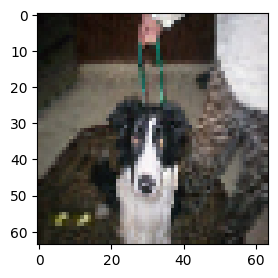

In [173]:
plt.figure(figsize = (3,3))
plt.imshow(images[6])

In [174]:
# Entrenar el modelo

clasificador.fit(
    training_set,
    validation_data = test_set,
    epochs = 5 # numero de veces que el modelo va a ver BD
)

Epoch 1/5
252/252 ━━━━━━━━━━━━━━━━━━━━ 43s 166ms/step - accuracy: 0.5886 - loss: 0.6708 - val_accuracy: 0.6905 - val_loss: 0.6051
Epoch 2/5
252/252 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.6792 - loss: 0.5967 - val_accuracy: 0.7340 - val_loss: 0.5528
Epoch 3/5
252/252 ━━━━━━━━━━━━━━━━━━━━ 44s 175ms/step - accuracy: 0.7182 - loss: 0.5478 - val_accuracy: 0.7335 - val_loss: 0.5428
Epoch 4/5
252/252 ━━━━━━━━━━━━━━━━━━━━ 45s 177ms/step - accuracy: 0.7393 - loss: 0.5256 - val_accuracy: 0.7155 - val_loss: 0.5665
Epoch 5/5
252/252 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.7625 - loss: 0.4916 - val_accuracy: 0.7690 - val_loss: 0.4840


In [175]:
# Validación del modelo

from tensorflow.keras.preprocessing import image

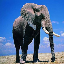

In [183]:
test_image = image.load_img(r"Captura de pantalla 2026-07-09 164434.png", target_size = (64,64))
test_image

In [184]:
test_image = image.img_to_array(test_image)

In [185]:
test_image = np.expand_dims(test_image, axis = 0)
test_image

array([[[[  8.,  78., 176.],
         [  9.,  80., 176.],
         [ 11.,  81., 183.],
         ...,
         [ 22., 103., 217.],
         [ 22., 102., 217.],
         [ 21., 102., 216.]],

        [[  8.,  78., 178.],
         [  9.,  79., 179.],
         [ 11.,  80., 185.],
         ...,
         [ 24., 105., 219.],
         [ 22., 103., 217.],
         [ 22., 102., 217.]],

        [[  8.,  78., 179.],
         [ 10.,  79., 184.],
         [ 11.,  80., 189.],
         ...,
         [ 22., 105., 218.],
         [ 23., 104., 218.],
         [ 23., 104., 218.]],

        ...,

        [[133., 135., 115.],
         [160., 153., 138.],
         [168., 159., 156.],
         ...,
         [183., 164., 141.],
         [170., 152., 126.],
         [164., 146., 122.]],

        [[163., 163., 143.],
         [167., 165., 144.],
         [122., 120., 100.],
         ...,
         [181., 159., 135.],
         [ 98.,  76.,  44.],
         [151., 127.,  92.]],

        [[149., 147., 127.],
       

In [186]:
resultado = clasificador.predict(test_image)
resultado

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[1.]], dtype=float32)

In [187]:
training_set.class_indices

{'cats': 0, 'dogs': 1}

In [188]:
resultado[0][0]

np.float32(1.0)

In [189]:
if resultado[0][0] > 0.5:
    print("Es un perro")
else:
    print("Es un gato")

Es un perro
